In [10]:
from pathlib import Path
import requests

DATA_PATH = Path("./dataset")
PATH = DATA_PATH/"mnist"

PATH.mkdir(parents=True,exist_ok= True)

URL = "http://deeplearning.net/data/mnist"
FILENAME = "mnist.pkl.gz"

if not (PATH/FILENAME).exists():
    content = requests.get(URL + FILENAME).content
    (PATH / FILENAME).open('wb').write(content)

In [2]:
import pickle
import gzip

with gzip.open(("./dataset/mnist/mnist.pkl.gz"),'rb') as f:
    ((x_train, y_train),(x_valid, y_valid), _)= pickle.load(f,encoding="latin-1")

784是28*28*1,是数据集每个样本的像素点个数

(50000, 784)


array([5, 0, 4, ..., 8, 4, 8], dtype=int64)

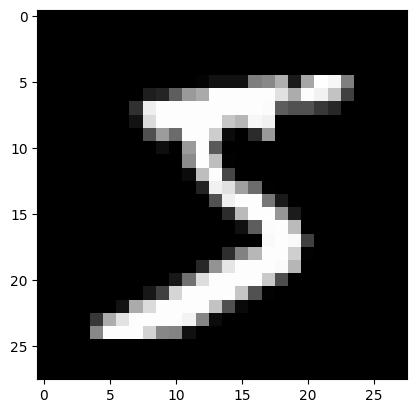

In [3]:
from matplotlib import pyplot as plt 
import numpy as np

plt.imshow(x_train[0].reshape((28,28)), cmap = "gray")
print(x_train.shape)

In [14]:
import torch

x_train, y_train, x_valid, y_valid = map(torch.tensor , (x_train, y_train, x_valid, y_valid))

n,c = x_train.shape

x_train, x_train.shape ,y_train.min(), y_train.max()

print(x_train , y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

d:\Anconda\envs\Paddle_tutorial\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


### torch.nn.functional 很多层和函数都会见到

一般情况下,如果模型有可学习的参数,最好用nn.Module,其它情况下nn.functional相对更简单一些

In [15]:
import torch.nn.functional as F

loss_func = F.cross_entropy

def model(xb):
    return xb.mm(weights)+bias

In [19]:
bs = 64
xb = x_train[0:bs]
yb = y_valid[0:bs]

weights = torch.randn([784,10], dtype = torch.float, requires_grad = True)
bs = 64
bias = torch.zeros(10,requires_grad=True)

print(loss_func(model(xb),yb))


tensor(18.8254, grad_fn=<NllLossBackward0>)


### 创建一个model来简化代码
* 必须继承nn.Moudule且在其构造函数中需能调用nn.Moudule的构造函数
* 无需写反向传播函数,nn.Moudule能够利用autograd自动实现反向传播
* Moudule中的可学习参数可以通过named_parameters()或者parameters()返回迭代器

In [35]:
from torch import nn

class Mnist_NN(nn.Module):## nn.Moudule做继承
    def __init__(self):
        super(Mnist_NN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Pass x through the Linear layer and then apply ReLU
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [21]:
net = Mnist_NN()
print(net)

Mnist_NN(
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=10, bias=True)
)


可以打印我们定义好的名字里的权重和偏置项

In [22]:
for name, parameter in net.named_parameters():
    print(name, parameter,parameter.size())

hidden1.weight Parameter containing:
tensor([[ 0.0147,  0.0312, -0.0341,  ...,  0.0347, -0.0150,  0.0091],
        [-0.0082,  0.0093,  0.0293,  ...,  0.0274, -0.0145,  0.0260],
        [-0.0347,  0.0078, -0.0321,  ...,  0.0041,  0.0181,  0.0122],
        ...,
        [-0.0258, -0.0336,  0.0035,  ...,  0.0223, -0.0001, -0.0162],
        [-0.0179,  0.0346,  0.0247,  ..., -0.0129,  0.0260,  0.0355],
        [-0.0177, -0.0284, -0.0332,  ..., -0.0322, -0.0024, -0.0090]],
       requires_grad=True) torch.Size([128, 784])
hidden1.bias Parameter containing:
tensor([ 8.5022e-03,  2.3567e-02, -2.0836e-02, -2.8763e-02, -2.9734e-02,
         6.1083e-03, -2.3193e-02, -1.6830e-02,  1.9804e-02, -9.4937e-03,
        -2.8328e-02,  1.1396e-02,  2.9494e-02, -1.7359e-02,  1.0956e-02,
        -3.5549e-02,  1.9156e-02, -2.1615e-04,  2.6394e-02,  3.4772e-02,
        -3.0827e-02, -1.4873e-02,  7.6085e-04, -9.1725e-03, -1.7926e-02,
         8.4663e-03, -1.4284e-04, -3.3494e-03, -1.5400e-02,  2.0845e-02,
      

### 使用TensorDataset和DataLoader来简化

In [23]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=bs*2)

In [33]:
def get_data(train_ds, valid_ds, bs):
    return(
        DataLoader(train_ds, batch_size=bs, shuffle=True),
        DataLoader(valid_ds,batch_size = bs*2),
    )

* 一般训练模型时加上model.train(),这样会正常使用Batch Normalization 和 Dropout
* 测试的时候一般选择model.eval(),这样就不会使用Batch Normalization和 Dropout

In [37]:
import numpy as np

def fit(steps, model, loss_func, opt, train_dl, valid_dl):
    for step in range(steps):
        model.train()#指明这里是模型训练阶段
        for xb,yb in train_dl:
            loss_batch(model, loss_func, xb, yb, opt)

        model.eval()#指明这里是模型评价阶段
        with torch.no_grad():
            losses, nums = zip(
                *[loss_batch(model, loss_func,xb,yb)for xb,yb in valid_dl]
            )
        val_loss = np.sum(np.multiply(losses,nums))/np.sum(nums)
        print('当前step:'+str(step),'验证集损失：'+str(val_loss))

In [27]:
from torch import optim

def get_model():
    model = Mnist_NN()
    return model,optim.SGD(model.parameters(),lr = 0.001)

In [31]:
def loss_batch (model, loss_func, xb, yb, opt = None):
    loss = loss_func(model(xb),yb) #损失值

    if opt is not None: #优化器
        loss.backward()
        opt.step()
        opt.zero_grad()

    return loss.item(),len(xb)

In [38]:
train_dl,valid_dl = get_data(train_ds,valid_ds,bs)
model,opt = get_model()
fit(25, model, loss_func, opt, train_dl, valid_dl)

当前step:0 验证集损失：2.283198659515381
当前step:1 验证集损失：2.2537628070831297
当前step:2 验证集损失：2.210187348937988
当前step:3 验证集损失：2.1447620346069334
当前step:4 验证集损失：2.0446631992340087
当前step:5 验证集损失：1.893891819190979
当前step:6 验证集损失：1.6892157558441163
当前step:7 验证集损失：1.4555887042999267
当前step:8 验证集损失：1.2360355234146119
当前step:9 验证集损失：1.0618248704910278
当前step:10 验证集损失：0.9333259138107299
当前step:11 验证集损失：0.8372052361488342
当前step:12 验证集损失：0.7631283557891846
当前step:13 验证集损失：0.7026210667610169
当前step:14 验证集损失：0.6530440465927124
当前step:15 验证集损失：0.6114373960494995
当前step:16 验证集损失：0.5758406675338745
当前step:17 验证集损失：0.5458076421737671
当前step:18 验证集损失：0.5192652868270874
当前step:19 验证集损失：0.49625000233650207
当前step:20 验证集损失：0.47729388871192935
当前step:21 验证集损失：0.4595251789093018
当前step:22 验证集损失：0.44462475485801695
当前step:23 验证集损失：0.43165403022766113
当前step:24 验证集损失：0.4191058617591858
